## Referencia histórica — no ejecutar como pipeline vigente

Este cuadernillo conserva la lógica original y su estado de ejecución histórico, que puede ser parcial o contener errores antiguos. Se preserva para consulta; no se han regenerado sus exportaciones retiradas.

Las limpiezas oficiales **03/05** y los notebooks de análisis **06/07** contienen esa lógica contrastada y sus resultados están ejecutados. Para revisar el flujo actual completo, consultar `Notebooks/README.md` y `GUIA_PASO_A_PASO_DATOS_Y_MODELOS.md` de la raíz. No interpretar resultados antiguos como resultados de la base vigente.

# 03 · Benchmark del estimado del ingeniero
## Todo para la finca Gaitana y Arabella.+

Este notebook responde una pregunta concreta: **¿qué tan cerca estuvo el estimado enviado por el ingeniero de la producción real de la semana siguiente?**

In [1]:
#Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

import re
import zipfile
from openpyxl import load_workbook


## **Importanción de estimados y llegada a la base de datos cruda.**

Primera parte, importación de las dinámicas completas y pasar a bases crudas de estimados reales.

In [ ]:
import os
import re
import pandas as pd


# ============================================================
# RUTA DE LOS ESTIMADOS
# ============================================================

ruta_real = r"C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Estimados semanales\2026"



# ============================================================
# BUSCAR ARCHIVOS VALIDOS
# Excluye ajustados
# ============================================================

archivos = []

for archivo in os.listdir(ruta_real):

    if archivo.lower().endswith(".xlsx"):

        if "ajust" not in archivo.lower():

            archivos.append(archivo)



print("Archivos encontrados:", len(archivos))



# ============================================================
# EXTRAER SEMANA INICIAL DEL NOMBRE
#
# Ejemplos:
#
# Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx
# -> 1
#
# Estimado Sem 03-08 2026 Gaitana-Arabella.xlsx
# -> 3
#
# ============================================================

def extraer_semana_inicio(nombre):

    resultado = re.search(
        r"sem\s*[- ]?(\d+)",
        nombre.lower()
    )


    if resultado:

        return int(resultado.group(1))


    return None




# ============================================================
# CREAR CONTROL DE ARCHIVOS
# ============================================================


control_archivos = []


for archivo in archivos:


    semana = extraer_semana_inicio(
        archivo
    )


    if semana is not None:


        control_archivos.append(
            {
                "archivo": archivo,
                "sem_inicio": semana
            }
        )



control = pd.DataFrame(
    control_archivos
)



control = (
    control
    .sort_values("sem_inicio")
    .reset_index(drop=True)
)



print(control)



# ============================================================
# BUSCAR ARCHIVO PARA UNA SEMANA
#
# REGLA:
#
# 1. Si existe archivo de esa semana -> usarlo
#
# 2. Si no existe -> usar el siguiente disponible
#
# Ej:
#
# Semana 1 -> sem 1
# Semana 2 -> sem 3
# Semana 3 -> sem 3
#
# ============================================================


def buscar_archivo_semana(semana):


    # Buscar coincidencia exacta

    archivo_exacto = control[
        control["sem_inicio"] == semana
    ]


    if not archivo_exacto.empty:


        return archivo_exacto.iloc[0]["archivo"]



    # Si no existe, buscar siguiente archivo

    archivo_siguiente = control[
        control["sem_inicio"] > semana
    ]


    if not archivo_siguiente.empty:


        return (
            archivo_siguiente
            .sort_values("sem_inicio")
            .iloc[0]["archivo"]
        )



    return None





# ============================================================
# LEER ARCHIVO COMPLETO
#
# NO hacemos resumen.
# Conservamos todo lo que Excel tenga.
#
# Equivalente a sacar la información cruda.
#
# ============================================================


def leer_archivo_crudo(archivo):


    ruta = os.path.join(
        ruta_real,
        archivo
    )


    hojas = pd.ExcelFile(
        ruta
    ).sheet_names



    tablas = []


    for hoja in hojas:


        df = pd.read_excel(
            ruta,
            sheet_name=hoja,
            header=None
        )


        # Guardamos trazabilidad

        df["archivo_origen"] = archivo

        df["hoja_origen"] = hoja



        tablas.append(df)



    base = pd.concat(
        tablas,
        ignore_index=True
    )



    return base





# ============================================================
# CREAR DICCIONARIO ESTIMADOS
# ============================================================


estimados = {}



# Última semana disponible

ultima_semana = control["sem_inicio"].max()



for semana in range(1, ultima_semana + 1):


    archivo = buscar_archivo_semana(
        semana
    )


    if archivo is not None:


        print(
            f"Semana {semana} <- {archivo}"
        )



        base = leer_archivo_crudo(
            archivo
        )


        # Guardamos semana analizada

        base["semana_analisis"] = semana



        estimados[semana] = base



print("\nProceso terminado")

print(
    "Semanas cargadas:",
    list(estimados.keys())
)

Archivos encontrados: 36
                                              archivo  sem_inicio
0         Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx           1
1       Estimado Sem 03-08 2026 Gaitana-Arabella.xlsx           3
2              Estimado sem 4-8 2026 LG+AR envio.xlsx           4
3              estimado sem 5-9 2026 LG+AR envio.xlsx           5
4             Estimado sem 6-10 2026 LG+AR envio.xlsx           6
5             Estimado sem 7-11 2026 LG+AR envio.xlsx           7
6             Estimado sem 8-12 2026 LG+AR envio.xlsx           8
7             Estimado sem 9-13 2026 LG+AR envio.xlsx           9
8            Estimado sem 10-14 2026 LG+AR envio.xlsx          10
9            Estimado sem 11-19 2026 LG+AR envio.xlsx          11
10           Estimado sem 12-19 2026 LG+AR envio.xlsx          12
11           Estimado sem 13-19 2026 AR+LG envio.xlsx          13
12           Estimado sem 14-19 2026 AR+LG envio.xlsx          14
13           Estimado sem 15-19 2026 LG+AR envio.xl

In [ ]:
# ============================================================
# EXTRAER H1-H5 DESDE LA BASE CRUDA DE LA TABLA DINÁMICA
#
# Para cada semana inicial solicitada:
# 1. usa buscar_archivo_semana();
# 2. si falta el archivo exacto, usa el siguiente disponible;
# 3. extrae TIPO = ESTIMADO desde la semana solicitada hasta H5;
# 4. conserva trazabilidad del archivo realmente utilizado.
# ============================================================

from datetime import date, timedelta
from pathlib import Path
from zipfile import ZipFile
from lxml import etree


NS_EXCEL = "http://schemas.openxmlformats.org/spreadsheetml/2006/main"
ANIO_ANALISIS = 2026
NUMERO_HORIZONTES = 5


def _valor_cache(elemento, valores_compartidos):
    """Convierte una celda comprimida de la caché de Excel a un valor de Python."""

    tipo = etree.QName(elemento).localname

    if tipo == "m":
        return None

    valor = elemento.get("v")

    if tipo == "x":
        indice = int(valor)
        return valores_compartidos[indice] if indice < len(valores_compartidos) else None

    if tipo == "n":
        numero = float(valor)
        return int(numero) if numero.is_integer() else numero

    if tipo == "b":
        return valor == "1"

    return valor


def construir_horizontes(anio_inicial, semana_inicial, numero_horizontes=5):
    """Construye H1-H5 respetando correctamente el cambio de año ISO."""

    lunes_inicial = date.fromisocalendar(anio_inicial, semana_inicial, 1)
    horizontes = []

    for semanas_adelante in range(numero_horizontes):
        lunes_objetivo = lunes_inicial + timedelta(weeks=semanas_adelante)
        iso = lunes_objetivo.isocalendar()

        horizontes.append({
            "anio_objetivo": iso.year,
            "semana_objetivo": iso.week,
            "horizonte": semanas_adelante + 1,
            "semanas_adelante": semanas_adelante,
            "lunes_objetivo": pd.Timestamp(lunes_objetivo)
        })

    return pd.DataFrame(horizontes)


def extraer_estimados_del_archivo(archivo, anios_interes):
    """Lee una caché una sola vez y devuelve todos sus ESTIMADOS de los años requeridos."""

    ruta_archivo = Path(ruta_real) / archivo
    anios_interes = set(anios_interes)

    with ZipFile(ruta_archivo) as libro:

        definiciones = sorted(
            nombre for nombre in libro.namelist()
            if "pivotCache/pivotCacheDefinition" in nombre
            and "/_rels/" not in nombre
        )
        registros = sorted(
            nombre for nombre in libro.namelist()
            if "pivotCache/pivotCacheRecords" in nombre
        )

        if not definiciones or not registros:
            raise ValueError(f"El archivo no conserva una caché de tabla dinámica: {archivo}")

        definicion = etree.fromstring(libro.read(definiciones[0]))
        campos_xml = definicion.find(f"{{{NS_EXCEL}}}cacheFields")
        columnas = [campo.get("name") for campo in campos_xml]

        requeridas = {"TIPO", "AÑO", "SEMANA", "ESTI. EXPORTABLE"}
        faltantes = requeridas.difference(columnas)
        if faltantes:
            raise ValueError(f"Faltan campos en la caché de {archivo}: {sorted(faltantes)}")

        compartidos = []
        for campo in campos_xml:
            bloque = campo.find(f"{{{NS_EXCEL}}}sharedItems")
            compartidos.append(
                [] if bloque is None
                else [_valor_cache(elemento, []) for elemento in bloque]
            )

        indice_tipo = columnas.index("TIPO")
        indice_anio = columnas.index("AÑO")
        filas = []

        # iterparse procesa los ~107 MB descomprimidos sin cargarlos completos en memoria.
        with libro.open(registros[0]) as flujo:
            contexto = etree.iterparse(
                flujo,
                events=("end",),
                tag=f"{{{NS_EXCEL}}}r"
            )

            for _, registro in contexto:
                celdas = list(registro)

                if len(celdas) == len(columnas):
                    tipo = _valor_cache(celdas[indice_tipo], compartidos[indice_tipo])
                    valor_anio = _valor_cache(celdas[indice_anio], compartidos[indice_anio])

                    if str(tipo).strip().upper() == "ESTIMADO" and valor_anio in anios_interes:
                        filas.append({
                            nombre: _valor_cache(celda, compartidos[posicion])
                            for posicion, (nombre, celda) in enumerate(zip(columnas, celdas))
                        })

                registro.clear()
                padre = registro.getparent()
                while registro.getprevious() is not None:
                    del padre[0]

    resultado = pd.DataFrame(filas, columns=columnas)
    resultado["archivo_origen"] = archivo
    resultado["semana_archivo"] = extraer_semana_inicio(archivo)

    return resultado


def preparar_estimado_h1_h5(
    base_archivo,
    semana_inicial,
    anio_inicial=2026,
    numero_horizontes=5
):
    """Selecciona H1-H5 respecto a la semana solicitada y agrega trazabilidad."""

    horizontes = construir_horizontes(
        anio_inicial=anio_inicial,
        semana_inicial=semana_inicial,
        numero_horizontes=numero_horizontes
    )

    base = base_archivo.copy()
    base["AÑO"] = pd.to_numeric(base["AÑO"], errors="coerce").astype("Int64")
    base["SEMANA"] = pd.to_numeric(base["SEMANA"], errors="coerce").astype("Int64")

    resultado = base.merge(
        horizontes,
        left_on=["AÑO", "SEMANA"],
        right_on=["anio_objetivo", "semana_objetivo"],
        how="inner",
        validate="many_to_one"
    )

    resultado["anio_inicial_estimado"] = anio_inicial
    resultado["semana_inicial_estimado"] = semana_inicial
    resultado["lunes_inicial_estimado"] = pd.Timestamp(
        date.fromisocalendar(anio_inicial, semana_inicial, 1)
    )

    semana_archivo = resultado["semana_archivo"].iloc[0] if len(resultado) else base["semana_archivo"].iloc[0]
    lunes_archivo = date.fromisocalendar(anio_inicial, int(semana_archivo), 1)
    lunes_solicitado = date.fromisocalendar(anio_inicial, semana_inicial, 1)
    diferencia = (lunes_archivo - lunes_solicitado).days // 7

    resultado["archivo_es_posterior"] = diferencia > 0
    resultado["diferencia_semanas_archivo"] = diferencia

    columnas_trazabilidad = [
        "anio_inicial_estimado", "semana_inicial_estimado", "horizonte",
        "semanas_adelante", "anio_objetivo", "semana_objetivo",
        "lunes_inicial_estimado", "lunes_objetivo", "archivo_origen",
        "semana_archivo", "archivo_es_posterior", "diferencia_semanas_archivo"
    ]
    columnas_base = [c for c in resultado.columns if c not in columnas_trazabilidad]

    return resultado[columnas_trazabilidad + columnas_base]


# ============================================================
# DICCIONARIO FINAL Y BASE CONSOLIDADA
# ============================================================

estimados_crudos = {}
cache_archivos = {}

for semana_inicial in range(1, ultima_semana + 1):

    archivo = buscar_archivo_semana(semana_inicial)

    if archivo is None:
        continue

    horizontes = construir_horizontes(
        ANIO_ANALISIS,
        semana_inicial,
        NUMERO_HORIZONTES
    )
    anios_necesarios = tuple(sorted(horizontes["anio_objetivo"].unique()))
    llave_cache = (archivo, anios_necesarios)

    # Si dos semanas usan el mismo archivo, la caché pesada se lee una sola vez.
    if llave_cache not in cache_archivos:
        print(f"Leyendo caché: {archivo}")
        cache_archivos[llave_cache] = extraer_estimados_del_archivo(
            archivo=archivo,
            anios_interes=anios_necesarios
        )

    estimados_crudos[semana_inicial] = preparar_estimado_h1_h5(
        base_archivo=cache_archivos[llave_cache],
        semana_inicial=semana_inicial,
        anio_inicial=ANIO_ANALISIS,
        numero_horizontes=NUMERO_HORIZONTES
    )

    disponibles = sorted(
        estimados_crudos[semana_inicial]["horizonte"].dropna().unique().tolist()
    )
    print(
        f"Semana inicial {semana_inicial}: {len(estimados_crudos[semana_inicial]):,} filas "
        f"| horizontes disponibles: {disponibles}"
    )


estimados_crudos_consolidados = (
    pd.concat(estimados_crudos.values(), ignore_index=True)
    if estimados_crudos
    else pd.DataFrame()
)


# Control explícito: permite detectar H1-H5 ausentes sin convertirlos en cero.
control_esperado = pd.MultiIndex.from_product(
    [sorted(estimados_crudos), range(1, NUMERO_HORIZONTES + 1)],
    names=["semana_inicial_estimado", "horizonte"]
).to_frame(index=False)

if estimados_crudos_consolidados.empty:
    control_extraccion = control_esperado.assign(registros=0, disponible=False)
else:
    conteos = (
        estimados_crudos_consolidados
        .groupby(["semana_inicial_estimado", "horizonte"], as_index=False)
        .size()
        .rename(columns={"size": "registros"})
    )
    control_extraccion = control_esperado.merge(
        conteos,
        on=["semana_inicial_estimado", "horizonte"],
        how="left"
    )
    control_extraccion["registros"] = control_extraccion["registros"].fillna(0).astype(int)
    control_extraccion["disponible"] = control_extraccion["registros"].gt(0)


print("\nProceso terminado")
print("Semanas en estimados_crudos:", list(estimados_crudos.keys()))
print("Filas consolidadas:", f"{len(estimados_crudos_consolidados):,}")
display(control_extraccion)

Leyendo caché: Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx
Semana inicial 1: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado Sem 03-08 2026 Gaitana-Arabella.xlsx
Semana inicial 2: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Semana inicial 3: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado sem 4-8 2026 LG+AR envio.xlsx
Semana inicial 4: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: estimado sem 5-9 2026 LG+AR envio.xlsx
Semana inicial 5: 968 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado sem 6-10 2026 LG+AR envio.xlsx
Semana inicial 6: 968 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado sem 7-11 2026 LG+AR envio.xlsx
Semana inicial 7: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado sem 8-12 2026 LG+AR envio.xlsx
Semana inicial 8: 970 filas | horizontes disponibles: [1, 2, 3, 4, 5]
Leyendo caché: Estimado sem 9-13 2026 LG+AR env

,semana_inicial_estimado,horizonte,registros,disponible
0,1,1,194,True
1,1,2,194,True
2,1,3,194,True
3,1,4,194,True
4,1,5,194,True
...,...,...,...,...
180,37,1,205,True
181,37,2,205,True
182,37,3,205,True
183,37,4,205,True


**Estimados crudos consolidados** 

Es la base de datos de estimados estraída de las tablas dinámicas del ingeniero Ricardo 

In [ ]:
estimados_crudos_consolidados.head()

,anio_inicial_estimado,semana_inicial_estimado,horizonte,semanas_adelante,anio_objetivo,semana_objetivo,lunes_inicial_estimado,lunes_objetivo,archivo_origen,semana_archivo,...,CODFINCA,PRODUCTO,COLOR,VARIEDAD,ESTI. EXPORTABLE,TIPO,CODIGO,AÑO,SEMANA,variedades validas
0,2026,1,1,0,2026,1,2025-12-29,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,...,CABAÑA,Eryngium,Purple,Alpinium,14000,ESTIMADO,2026-1,2026,1,incluir
1,2026,1,1,0,2026,1,2025-12-29,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,...,CABAÑA,Eryngium,Purple,Tropical Snow,800,ESTIMADO,2026-1,2026,1,incluir
2,2026,1,2,1,2026,2,2025-12-29,2026-01-05,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,...,CABAÑA,Eryngium,Purple,Alpinium,14500,ESTIMADO,2026-2,2026,2,incluir
3,2026,1,2,1,2026,2,2025-12-29,2026-01-05,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,...,CABAÑA,Eryngium,Purple,Tropical Snow,900,ESTIMADO,2026-2,2026,2,incluir
4,2026,1,3,2,2026,3,2025-12-29,2026-01-12,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,...,CABAÑA,Eryngium,Purple,Alpinium,14350,ESTIMADO,2026-3,2026,3,incluir


In [ ]:
estimados_H1 = (
      estimados_crudos_consolidados
      .loc[estimados_crudos_consolidados["horizonte"] == 1]
      .copy()
      .reset_index(drop=True)
  )

estimados_H1.head()

estimados_H1.to_excel("estimados_H1.xlsx", index=False)

Hasta aqui lo que hemos hecho de tomar los estimados, extraerlos y consolidarlos en una sola base de datos. 

## **Importación de producción real y su respectiva limpieza**


In [2]:
ruta_real = r"C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Producción real\Producción Acumulada 2026.xlsx"

#aqui se importa el df de estimados_H1.xlsx para hacer el benchmark con el estimado del ingeniero
#pero también se importa la base de datos de producción real. a la que le vamos a hacer una limpieza y una homogenización apra unirla y ver que tanto es el error del ingeniero con respecto al estimado

df_prod_real = pd.read_excel(ruta_real, sheet_name="BD", header=0, engine="calamine")

df_prod_real.head()

,Finca,Sector,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Inventario Físico,Reintegro,Tipo Inventario,Ajuste,Fecha Descarga
0,Arabella,Cristina Benavides,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,bicolor yellow,Spritz,80.0,62982.0,Recepcion,9:53AM,NO,False,C,NaN,NaT
1,Arabella,Cristina Benavides,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30125.0,Recepcion,10:17AM,NO,False,C,NaN,NaT
2,Arabella,Cristina Benavides,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30750.0,Recepcion,9:54AM,NO,False,C,NaN,NaT
3,Arabella,Cristina Benavides,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30751.0,Clasificación,9:54AM,NO,False,C,NaN,NaT
4,Arabella,Cristina Benavides,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,31080.0,Clasificación,9:54AM,NO,False,C,NaN,NaT


In [3]:
estimados_H1 = pd.read_excel("estimados_H1.xlsx")


### Limpieza y EDA

In [4]:
#Aqui quiero ver faltantes en los datos, tipos de dato  y cambiarlos a lo que necesito, quitar Sector, Inventario Físico, Reintegro, Ajuste, Fecha Descarga en columnas

# ============================================================
# LIMPIEZA INICIAL DE LA PRODUCCIÓN REAL
# ============================================================

# Trabajamos sobre una copia para conservar la información original
df_prod_clean = df_prod_real.copy()

# Limpiar posibles espacios en los nombres de las columnas
df_prod_clean.columns = df_prod_clean.columns.str.strip()

# Columnas que no aportan al análisis de producción
columnas_eliminar = [
    "Sector",
    "Inventario Físico",
    "Reintegro",
    "Ajuste",
    "Fecha Descarga"
]

df_prod_clean.drop(
    columns=columnas_eliminar,
    inplace=True,
    errors="ignore"
)

print(f"Filas: {df_prod_clean.shape[0]:,}")
print(f"Columnas: {df_prod_clean.shape[1]}")

df_prod_clean.head()


Filas: 939,835
Columnas: 15


,Finca,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Tipo Inventario
0,Arabella,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,bicolor yellow,Spritz,80.0,62982.0,Recepcion,9:53AM,C
1,Arabella,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30125.0,Recepcion,10:17AM,C
2,Arabella,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30750.0,Recepcion,9:54AM,C
3,Arabella,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,30751.0,Clasificación,9:54AM,C
4,Arabella,Bloque 11,2025-12-29,2025.0,1.0,Corte 2,Carnation,Cinta verde,green,Prado Mint,80.0,31080.0,Clasificación,9:54AM,C


In [5]:
# Ahora aca vamos a ver los tipos de datos 

df_prod_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 939835 entries, 0 to 939834
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Finca              939805 non-null  str           
 1   Invernadero        939805 non-null  str           
 2   Fecha Corte        939805 non-null  datetime64[us]
 3   Año                939805 non-null  float64       
 4   Semana             939805 non-null  float64       
 5   Tipo Corte         928195 non-null  str           
 6   Producto           939805 non-null  str           
 7   Grado              939805 non-null  str           
 8   Color              939805 non-null  str           
 9   Variedad           939805 non-null  str           
 10  Tallos             939805 non-null  float64       
 11  Lote               939805 non-null  float64       
 12  Estado Inventario  939805 non-null  str           
 13  Hora Corte         939805 non-null  str           
 14 

In [6]:
#Vamos a ver cuales están full vacías 

# Cantidad de filas completamente vacías
filas_vacias = df_prod_clean.isna().all(axis=1).sum()

print(f"Filas completamente vacías: {filas_vacias:,}")

Filas completamente vacías: 30


<Figure size 1400x600 with 0 Axes>

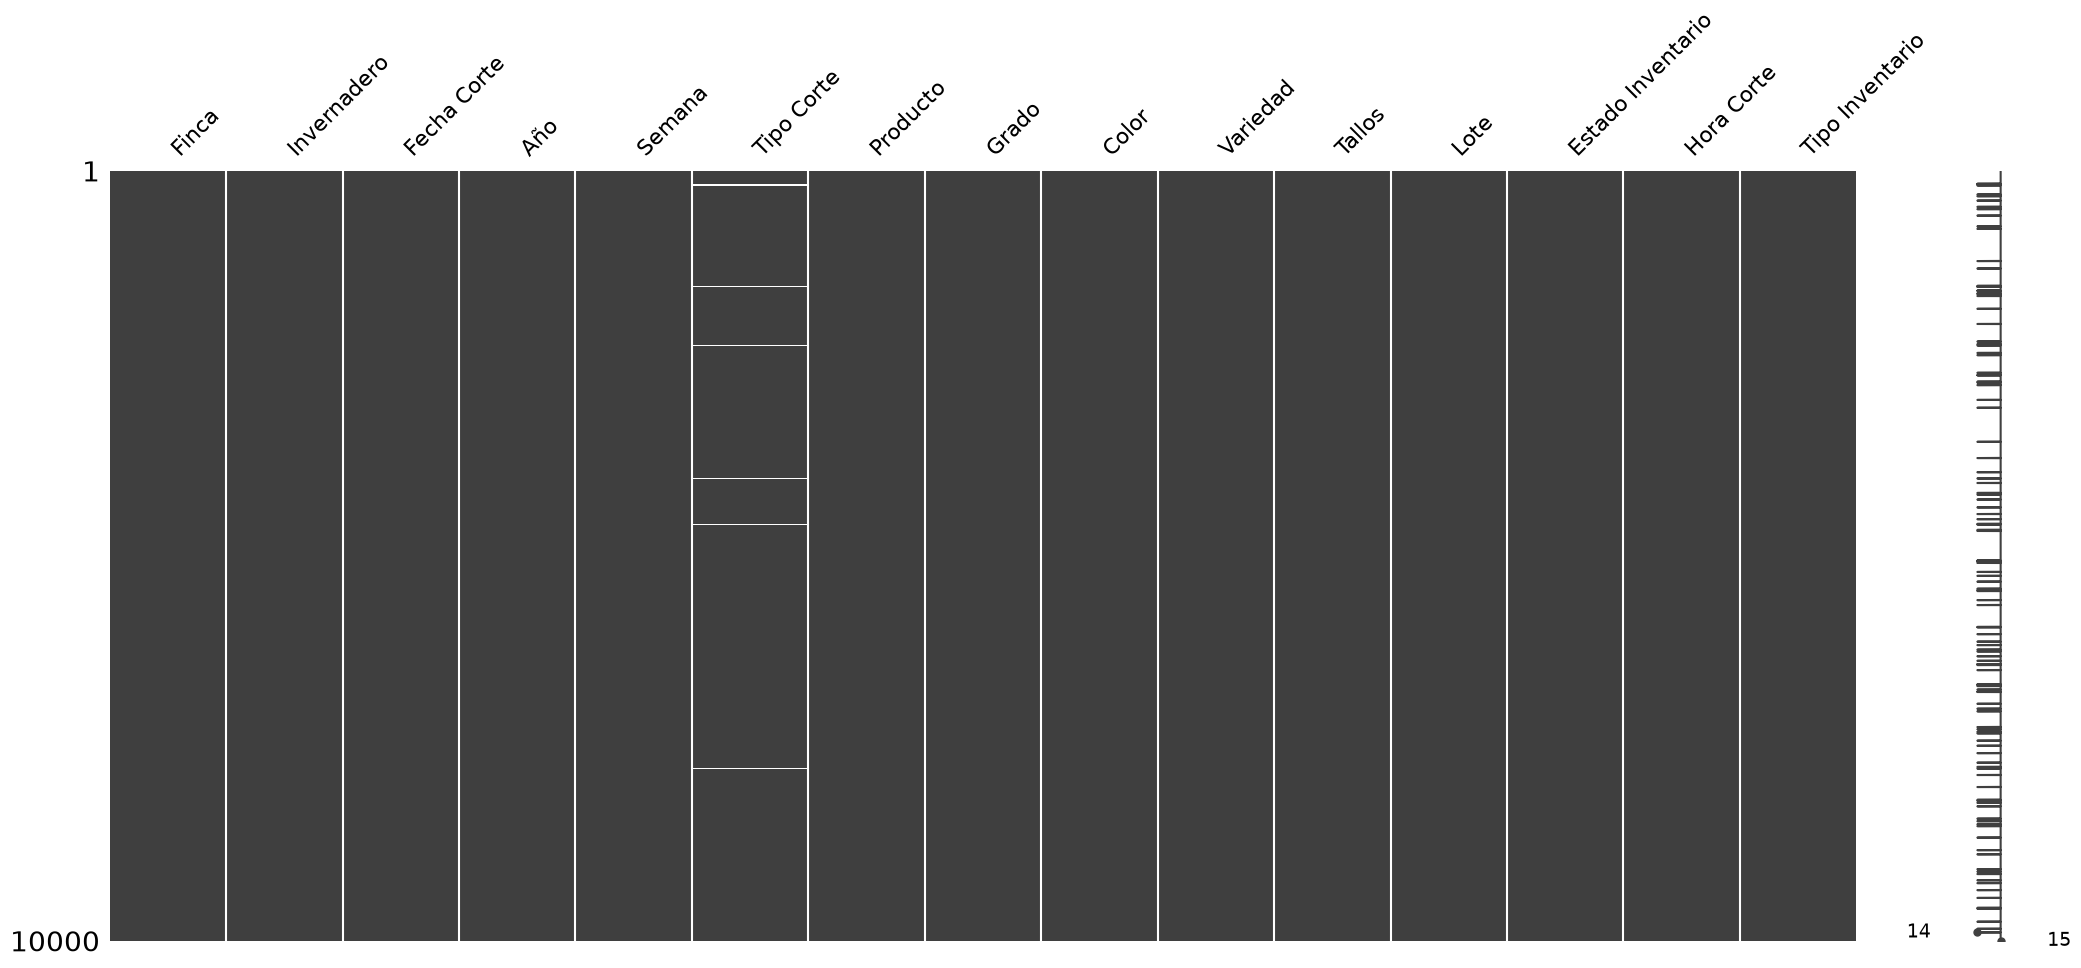

In [7]:
#Esto para ver si hay alguna matriz en la desaparición de datos, para ver si hay alguna correlación entre los datos que faltan y los que no faltan.

import missingno as msno
import matplotlib.pyplot as plt

# Visualización de datos faltantes
plt.figure(figsize=(14, 6))

msno.matrix(
    df_prod_clean.sample(
        n=min(10000, len(df_prod_clean)),
        random_state=42
    )
)

plt.show()

In [8]:
# Columnas clave para detectar filas realmente vacías
cols_clave = [
    "Finca", "Invernadero", "Fecha Corte", "Año", "Semana",
    "Tipo Corte", "Producto", "Grado", "Color", "Variedad",
    "Tallos", "Lote", "Estado Inventario", "Hora Corte", "Tipo Inventario"
]

# Detectar filas vacías
mask = df_prod_real[cols_clave].isna().all(axis=1)

# Crear bloques de vacíos consecutivos
grupo = mask.ne(mask.shift()).cumsum()

bloques = (
    df_prod_real[mask]
    .groupby(grupo[mask])
    .apply(lambda x: (x.index.min(), x.index.max()))
)

# Mostrar 5 filas antes y 5 después de los primeros 10 huecos
for inicio, fin in bloques.head(10):

    if inicio > 0 and fin < len(df_prod_real) - 1:

        print(f"\n{'='*100}")
        print(f"HUECO: {inicio} → {fin} | {fin-inicio+1} filas vacías")
        print(f"{'='*100}")

        print("\n⬆️  5 FILAS ANTES DEL HUECO")
        display(df_prod_real.loc[inicio-5:inicio-1])

        print("\n⬇️  5 FILAS DESPUÉS DEL HUECO")
        display(df_prod_real.loc[fin+1:fin+5])


HUECO: 94564 → 94593 | 30 filas vacías

⬆️  5 FILAS ANTES DEL HUECO


,Finca,Sector,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Inventario Físico,Reintegro,Tipo Inventario,Ajuste,Fecha Descarga
94559,GAITANA,Milton Pinzon,Bloque 32,2026-01-25,2026.0,4.0,Corte 2,Solomio,Granel,yellow,Blondfly,60.0,6899.0,Recepcion,11:57AM,NO,False,C,NaN,2025-01-22 07:36:19.770
94560,GAITANA,Milton Pinzon,Bloque 32,2026-01-25,2026.0,4.0,Corte 2,Solomio,Granel,yellow,Blondfly,60.0,6900.0,Recepcion,11:57AM,NO,False,C,NaN,2025-01-22 07:54:05.053
94561,GAITANA,Milton Pinzon,Bloque 32,2026-01-25,2026.0,4.0,Corte 2,Solomio,Granel,yellow,Blondfly,60.0,6901.0,Recepcion,11:57AM,NO,False,C,NaN,2025-01-26 10:43:25.160
94562,GAITANA,Milton Pinzon,Bloque 32,2026-01-25,2026.0,4.0,Corte 2,Solomio,Granel,yellow,Blondfly,60.0,6902.0,Recepcion,11:57AM,NO,False,C,NaN,2025-01-26 10:43:23.010
94563,GAITANA,Milton Pinzon,Bloque 32,2026-01-25,2026.0,4.0,Corte 2,Solomio,Granel,yellow,Blondfly,60.0,6903.0,Recepcion,11:57AM,NO,False,C,NaN,2025-01-25 11:29:11.533



⬇️  5 FILAS DESPUÉS DEL HUECO


,Finca,Sector,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Inventario Físico,Reintegro,Tipo Inventario,Ajuste,Fecha Descarga
94594,Arabella,Cristina Benavides,Bloque 11,2026-01-26,2026.0,5.0,Corte 2,Carnation,Granel,bicolor burgundy,Perfect,37.0,31414.0,Clasificación,11:41AM,NO,False,C,NaN,NaT
94595,Arabella,Cristina Benavides,Bloque 11,2026-01-26,2026.0,5.0,Corte 2,Carnation,Granel,bicolor burgundy,Perfect,80.0,31415.0,Clasificación,9:56AM,NO,False,C,NaN,2025-01-23 07:33:08.103
94596,Arabella,Cristina Benavides,Bloque 11,2026-01-26,2026.0,5.0,Corte 2,Carnation,Granel,bicolor burgundy,Perfect,20.0,31444.0,Clasificación,3:48PM,NO,False,C,NaN,2025-01-23 14:16:05.987
94597,Arabella,Cristina Benavides,Bloque 11,2026-01-26,2026.0,5.0,Corte 2,Carnation,Granel,bicolor burgundy,Perfect,80.0,31445.0,Clasificación,3:51PM,NO,False,C,NaN,2025-01-23 13:57:46.517
94598,Arabella,Cristina Benavides,Bloque 11,2026-01-26,2026.0,5.0,Corte 2,Carnation,Granel,bicolor pink,Antigua,48.0,62288.0,Clasificación,11:41AM,NO,False,C,NaN,2025-01-23 13:57:05.100


Bueno gracias a esto la decisión de diseño es eliminar las filas completamente vacias y hacer un reset de los índices

In [9]:
# Columnas que identifican un registro real de producción
cols_clave = [
    "Finca", "Invernadero", "Fecha Corte", "Año", "Semana",
    "Tipo Corte", "Producto", "Grado", "Color", "Variedad",
    "Tallos", "Lote", "Estado Inventario", "Hora Corte", "Tipo Inventario"
]

# Eliminar filas sin información de producción y reiniciar índice
df_prod_clean = (
    df_prod_clean
    .dropna(subset=cols_clave, how="all")
    .reset_index(drop=True)
)

print(f"Filas finales: {len(df_prod_clean):,}")

Filas finales: 939,805


<Figure size 1400x600 with 0 Axes>

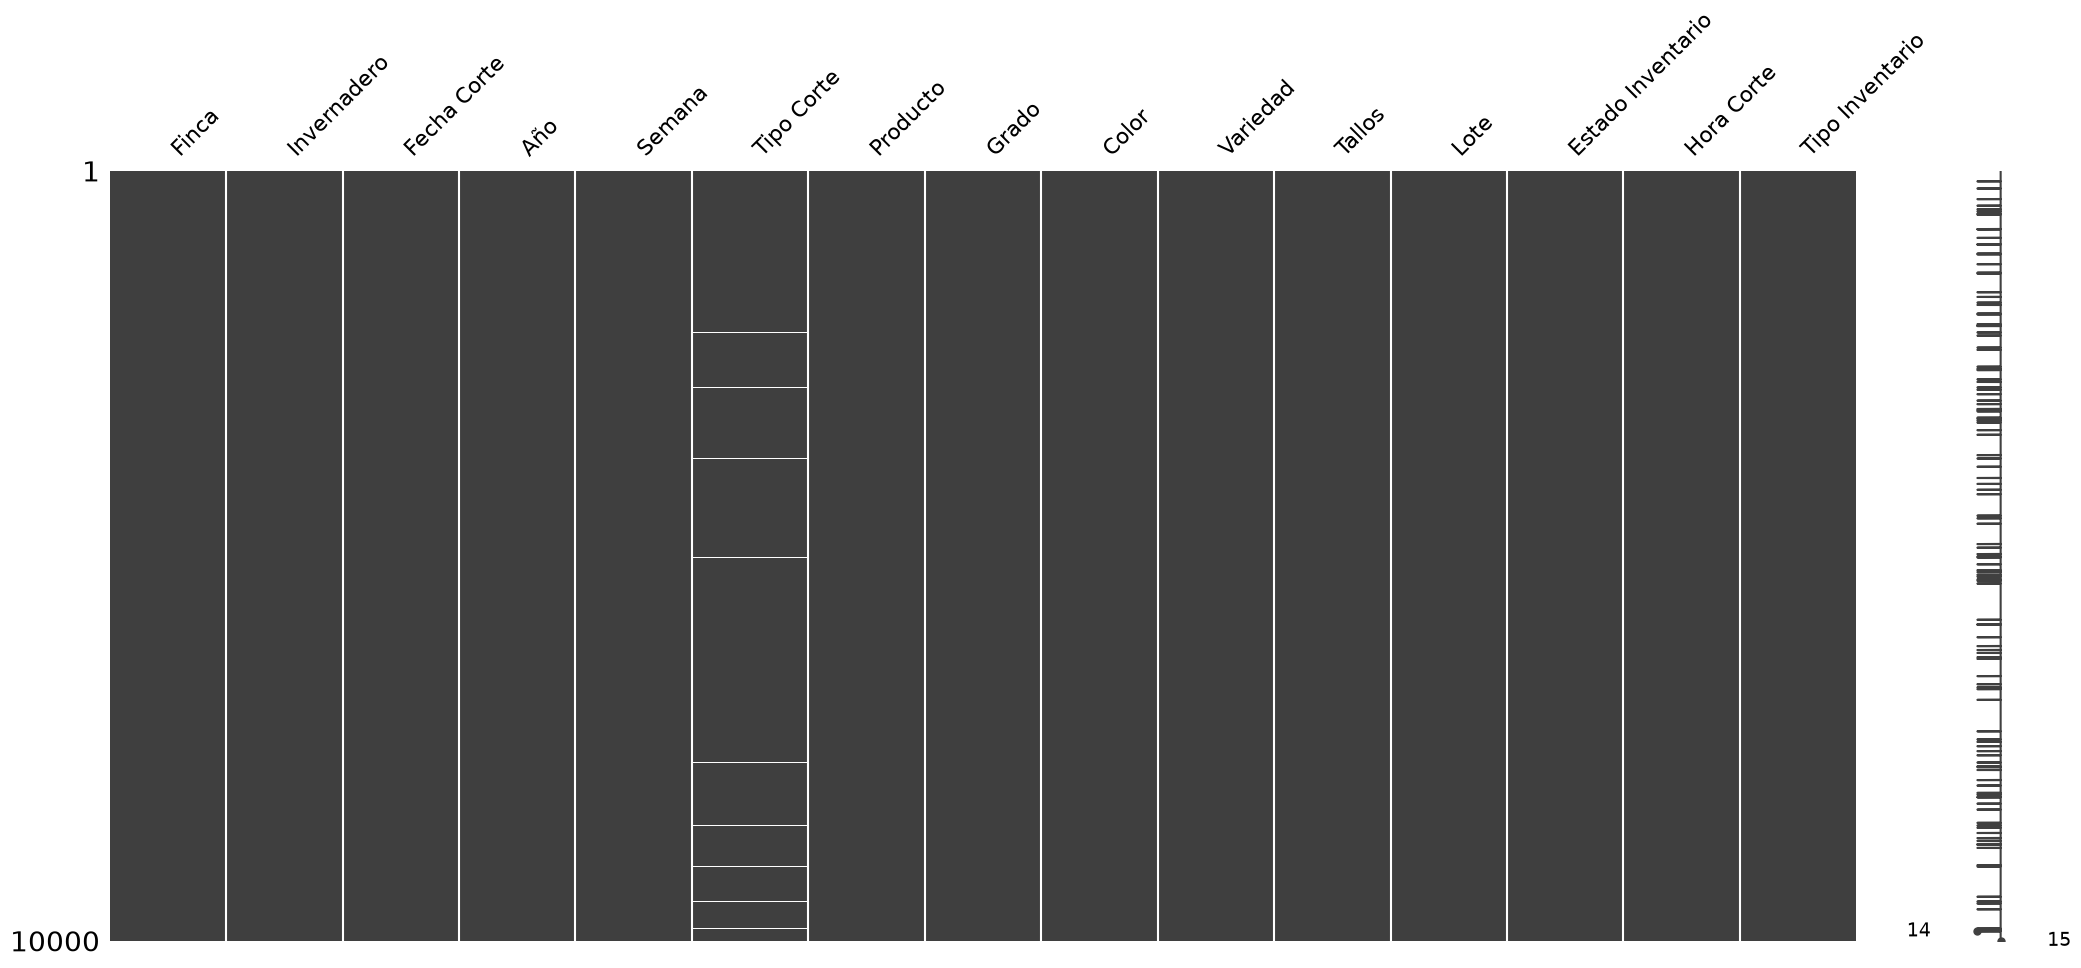

In [10]:
#Esto para ver si hay alguna matriz en la desaparición de datos, para ver si hay alguna correlación entre los datos que faltan y los que no faltan.

import missingno as msno
import matplotlib.pyplot as plt

# Visualización de datos faltantes
plt.figure(figsize=(14, 6))

msno.matrix(
    df_prod_clean.sample(
        n=min(10000, len(df_prod_clean)),
        random_state=42
    )
)

plt.show()

In [11]:
pd.DataFrame({
    "Faltantes": df_prod_clean.isna().sum(),
    "Porcentaje": (df_prod_clean.isna().mean() * 100).round(2)
}).query("Faltantes > 0")

,Faltantes,Porcentaje
Tipo Corte,11610,1.24


In [12]:
#Cómo es bien poquito la imputación de los datos lo vamos a hacer con la combinación PRODUCTO + COLOR + VARIEDAD... de la semana pasada, actual y una siguiente, cogiendo la mas frecuente... La idea es no perder nada de data.
# Semana calendario de cada registro
df_prod_clean["_semana"] = (
    df_prod_clean["Fecha Corte"]
    .dt.to_period("W-SUN")
    .dt.start_time
)

# Contar Tipo Corte por Producto + Color + Variedad + Semana
conteo = (
    df_prod_clean[df_prod_clean["Tipo Corte"].notna()]
    .groupby(
        ["Producto", "Color", "Variedad", "_semana", "Tipo Corte"]
    )
    .size()
    .reset_index(name="Cantidad")
)

# Para cada semana considerar: anterior, actual y siguiente
candidatos = pd.concat([
    conteo.assign(SemanaObjetivo=conteo["_semana"] - pd.Timedelta(days=7)),
    conteo.assign(SemanaObjetivo=conteo["_semana"]),
    conteo.assign(SemanaObjetivo=conteo["_semana"] + pd.Timedelta(days=7))
])

# Sumar frecuencias dentro de las 3 semanas
candidatos = (
    candidatos
    .groupby(
        ["Producto", "Color", "Variedad", "SemanaObjetivo", "Tipo Corte"],
        as_index=False
    )["Cantidad"]
    .sum()
)

# Escoger el Tipo Corte más frecuente
moda = (
    candidatos
    .sort_values("Cantidad", ascending=False)
    .drop_duplicates(
        ["Producto", "Color", "Variedad", "SemanaObjetivo"]
    )
    .set_index(
        ["Producto", "Color", "Variedad", "SemanaObjetivo"]
    )["Tipo Corte"]
)

# Imputar solamente los valores faltantes
mask = df_prod_clean["Tipo Corte"].isna()

claves = pd.MultiIndex.from_frame(
    df_prod_clean.loc[
        mask,
        ["Producto", "Color", "Variedad", "_semana"]
    ].rename(columns={"_semana": "SemanaObjetivo"})
)

df_prod_clean.loc[mask, "Tipo Corte"] = moda.reindex(claves).to_numpy()

# Eliminar columna auxiliar
df_prod_clean.drop(columns="_semana", inplace=True)

# Revisar cuántos faltantes quedaron
print("Faltantes restantes:", df_prod_clean["Tipo Corte"].isna().sum())


pd.DataFrame({
    "Faltantes": df_prod_clean.isna().sum(),
    "Porcentaje": (df_prod_clean.isna().mean() * 100).round(2)
}).query("Faltantes > 0")

Faltantes restantes: 0


,Faltantes,Porcentaje


In [13]:
df_prod_clean["Hora Corte"] = pd.to_datetime(
    df_prod_clean["Hora Corte"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
).dt.time

In [14]:
df_prod_clean["Hora Corte"].head(10)

0    09:53:00
1    10:17:00
2    09:54:00
3    09:54:00
4    09:54:00
5    09:54:00
6    09:54:00
7    09:54:00
8    09:54:00
9    09:53:00
Name: Hora Corte, dtype: object

In [15]:
df_prod_clean["Hora Corte"].isna().sum()

np.int64(0)

In [16]:
# Cambiar tipos de datos

df_prod_clean["Año"] = df_prod_clean["Año"].astype(int)
df_prod_clean["Semana"] = df_prod_clean["Semana"].astype(int)
df_prod_clean["Tallos"] = df_prod_clean["Tallos"].astype(int)
df_prod_clean["Lote"] = df_prod_clean["Lote"].astype(int)

# Hora Corte -> tipo hora
df_prod_clean["Hora Corte"] = pd.to_datetime(
    df_prod_clean["Hora Corte"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
).dt.time

# Revisar resultado
df_prod_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 939805 entries, 0 to 939804
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Finca              939805 non-null  str           
 1   Invernadero        939805 non-null  str           
 2   Fecha Corte        939805 non-null  datetime64[us]
 3   Año                939805 non-null  int64         
 4   Semana             939805 non-null  int64         
 5   Tipo Corte         939805 non-null  str           
 6   Producto           939805 non-null  str           
 7   Grado              939805 non-null  str           
 8   Color              939805 non-null  str           
 9   Variedad           939805 non-null  str           
 10  Tallos             939805 non-null  int64         
 11  Lote               939805 non-null  int64         
 12  Estado Inventario  939805 non-null  str           
 13  Hora Corte         939805 non-null  object        
 14 

In [17]:
df_prod_clean

,Finca,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Tipo Inventario
0,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,bicolor yellow,Spritz,80,62982,Recepcion,09:53:00,C
1,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,30125,Recepcion,10:17:00,C
2,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,30750,Recepcion,09:54:00,C
3,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,30751,Clasificación,09:54:00,C
4,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,31080,Clasificación,09:54:00,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939800,GAITANA,Bloque 32,2026-09-05,2026,36,Corte 2,Solomio,Granel,yellow,Blondfly,90,23440,Recepcion,08:07:00,C
939801,GAITANA,Bloque 32,2026-09-05,2026,36,Corte 2,Solomio,Granel,yellow,Blondfly,90,23441,Recepcion,08:07:00,C
939802,GAITANA,Bloque 32,2026-09-05,2026,36,Corte 2,Solomio,Granel,yellow,Blondfly,90,23442,Recepcion,08:07:00,C
939803,GAITANA,Bloque 32,2026-09-05,2026,36,Corte 2,Solomio,Granel,yellow,Blondfly,90,23443,Recepcion,08:06:00,C


Ahora la limpieza de Estimados Horizonte 1 por aquello de que no se hizo arriba pero procesas las bases crudas se demora mucho

In [18]:
estimados_H1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7282 entries, 0 to 7281
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   anio_inicial_estimado       7282 non-null   int64         
 1   semana_inicial_estimado     7282 non-null   int64         
 2   horizonte                   7282 non-null   int64         
 3   semanas_adelante            7282 non-null   int64         
 4   anio_objetivo               7282 non-null   int64         
 5   semana_objetivo             7282 non-null   int64         
 6   lunes_inicial_estimado      7282 non-null   datetime64[us]
 7   lunes_objetivo              7282 non-null   datetime64[us]
 8   archivo_origen              7282 non-null   str           
 9   semana_archivo              7282 non-null   int64         
 10  archivo_es_posterior        7282 non-null   bool          
 11  diferencia_semanas_archivo  7282 non-null   int64         
 12  COD

In [19]:
pd.DataFrame({
    "Faltantes": estimados_H1.isna().sum(),
    "Porcentaje": (estimados_H1.isna().mean() * 100).round(2)
}).query("Faltantes > 0")

,Faltantes,Porcentaje


no hay faltantes

ahora vamos a mirar si podemos borrar algunas cosas, pues digamos si hay columna que son igualitas

1. comparación de lunes_inicial_estimado y lunes objetivo



In [20]:
# Revisar si las fechas son diferentes
print(
    "Filas donde lunes_inicial_estimado != lunes_objetivo:",
    (estimados_H1["lunes_inicial_estimado"] != estimados_H1["lunes_objetivo"]).sum()
)

# Ver algunos ejemplos
estimados_H1.loc[
    estimados_H1["lunes_inicial_estimado"] != estimados_H1["lunes_objetivo"],
    ["lunes_inicial_estimado", "lunes_objetivo", "semanas_adelante", "horizonte"]
].head(10)

Filas donde lunes_inicial_estimado != lunes_objetivo: 0


,lunes_inicial_estimado,lunes_objetivo,semanas_adelante,horizonte


efectivamente se puede eliminar

In [21]:
estimados_H1.drop(
    columns=[
        "variedades validas",
        "anio_objetivo",
        "semana_objetivo",
        "lunes_inicial_estimado",
        "horizonte"
    ],
    inplace=True,
    errors="ignore"
)

estimados_H1.head()

,anio_inicial_estimado,semana_inicial_estimado,semanas_adelante,lunes_objetivo,archivo_origen,semana_archivo,archivo_es_posterior,diferencia_semanas_archivo,CODFINCA,PRODUCTO,COLOR,VARIEDAD,ESTI. EXPORTABLE,TIPO,CODIGO,AÑO,SEMANA
0,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,CABAÑA,Eryngium,Purple,Alpinium,14000,ESTIMADO,2026-1,2026,1
1,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,CABAÑA,Eryngium,Purple,Tropical Snow,800,ESTIMADO,2026-1,2026,1
2,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Vintage,Antigua,2870,ESTIMADO,2026-1,2026,1
3,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Peach,Apple Tea,3120,ESTIMADO,2026-1,2026,1
4,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Orange,Arno,0,ESTIMADO,2026-1,2026,1


## **Unión de estimados y producción real para captar diferencias y definición de metricas semana a semana**

### 0. Print de las bases originales para no perder información importante

In [22]:
df_prod_clean.head(10)

,Finca,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Tipo Inventario
0,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,bicolor yellow,Spritz,80,62982,Recepcion,09:53:00,C
1,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,30125,Recepcion,10:17:00,C
2,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,30750,Recepcion,09:54:00,C
3,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,30751,Clasificación,09:54:00,C
4,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,31080,Clasificación,09:54:00,C
5,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,31081,Clasificación,09:54:00,C
6,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,green,Prado Mint,80,31082,Recepcion,09:54:00,C
7,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,hot pink,Zeppelin,80,231935,Recepcion,09:54:00,C
8,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,hot pink,Zeppelin,80,231936,Recepcion,09:54:00,C
9,Arabella,Bloque 11,2025-12-29,2025,1,Corte 2,Carnation,Cinta verde,orange,Gobi,80,69972,Clasificación,09:53:00,C


In [23]:
df_prod_clean['Finca'].unique()

<ArrowStringArray>
['Arabella', 'GAITANA', '¡']
Length: 3, dtype: str

In [24]:
df_prod_clean[df_prod_clean['Finca']=='¡']

,Finca,Invernadero,Fecha Corte,Año,Semana,Tipo Corte,Producto,Grado,Color,Variedad,Tallos,Lote,Estado Inventario,Hora Corte,Tipo Inventario
20021,¡,Bloque 11,2026-01-05,2026,2,Corte 2,Carnation,cinta blanca,burgundy,Zurigo,80,172634,Recepcion,14:24:00,C


In [25]:
estimados_H1['CODFINCA'].unique()

<ArrowStringArray>
['CABAÑA', 'GF', 'AR']
Length: 3, dtype: str

In [26]:
df_prod_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 939805 entries, 0 to 939804
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Finca              939805 non-null  str           
 1   Invernadero        939805 non-null  str           
 2   Fecha Corte        939805 non-null  datetime64[us]
 3   Año                939805 non-null  int64         
 4   Semana             939805 non-null  int64         
 5   Tipo Corte         939805 non-null  str           
 6   Producto           939805 non-null  str           
 7   Grado              939805 non-null  str           
 8   Color              939805 non-null  str           
 9   Variedad           939805 non-null  str           
 10  Tallos             939805 non-null  int64         
 11  Lote               939805 non-null  int64         
 12  Estado Inventario  939805 non-null  str           
 13  Hora Corte         939805 non-null  object        
 14 

In [27]:
estimados_H1.shape

(7282, 17)

In [28]:
estimados_H1.head(10)

,anio_inicial_estimado,semana_inicial_estimado,semanas_adelante,lunes_objetivo,archivo_origen,semana_archivo,archivo_es_posterior,diferencia_semanas_archivo,CODFINCA,PRODUCTO,COLOR,VARIEDAD,ESTI. EXPORTABLE,TIPO,CODIGO,AÑO,SEMANA
0,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,CABAÑA,Eryngium,Purple,Alpinium,14000,ESTIMADO,2026-1,2026,1
1,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,CABAÑA,Eryngium,Purple,Tropical Snow,800,ESTIMADO,2026-1,2026,1
2,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Vintage,Antigua,2870,ESTIMADO,2026-1,2026,1
3,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Peach,Apple Tea,3120,ESTIMADO,2026-1,2026,1
4,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Orange,Arno,0,ESTIMADO,2026-1,2026,1
5,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Bicolor Burgundy,Bacarat,0,ESTIMADO,2026-1,2026,1
6,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,White,Brisa,0,ESTIMADO,2026-1,2026,1
7,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Peach,Brut,7280,ESTIMADO,2026-1,2026,1
8,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Light Pink,Bublicius,1360,ESTIMADO,2026-1,2026,1
9,2026,1,0,2025-12-29,Estimado sem 1 a 8 de 2026 LG+AR envio.xlsx,1,False,0,GF,Carnation,Gold,Caroline Gold,3160,ESTIMADO,2026-1,2026,1


### 1. Preparar las dos bases

Se construyen nombres comparables, se corrige el año ISO desde `Fecha Corte`, se excluye La Cabaña y se eliminan estimados posteriores a la última semana con producción. No se reemplazan faltantes con cero.

In [29]:
import re
import unicodedata
from datetime import date


def limpiar_nombre(valor):
    if pd.isna(valor):
        return pd.NA

    texto = (
        unicodedata.normalize("NFKD", str(valor))
        .encode("ascii", "ignore")
        .decode()
    )

    texto = re.sub(r"\s+", " ", texto.strip().upper())

    return texto if texto else pd.NA


def limpiar_finca(valor):

    # Revisar este símbolo antes de que la limpieza lo elimine.
    if pd.notna(valor) and str(valor).strip() == "¡":
        return "GAITANA"

    nombre = limpiar_nombre(valor)

    mapa = {
        "GF": "GAITANA",
        "LA GAITANA": "GAITANA",
        "GAITANA": "GAITANA",
        "AR": "ARABELLA",
        "ARABELLA": "ARABELLA",
        "CABANA": "CABANA",
        "LA CABANA": "CABANA",
        "FINCA LA CABANA": "CABANA"
    }

    return mapa.get(nombre, nombre) if pd.notna(nombre) else pd.NA


est = estimados_H1.copy()
prod = df_prod_clean.copy()


if "horizonte" in est.columns:
    est = est[
        pd.to_numeric(est["horizonte"], errors="coerce").eq(1)
    ].copy()


# Llaves del estimado.
est["anio"] = pd.to_numeric(
    est["AÑO"],
    errors="coerce"
).astype("Int64")

est["semana"] = pd.to_numeric(
    est["SEMANA"],
    errors="coerce"
).astype("Int64")

est["k_finca"] = est["CODFINCA"].map(limpiar_finca)
est["k_producto"] = est["PRODUCTO"].map(limpiar_nombre)
est["k_color"] = est["COLOR"].map(limpiar_nombre)
est["k_variedad"] = est["VARIEDAD"].map(limpiar_nombre)

est["tallos_estimados"] = pd.to_numeric(
    est["ESTI. EXPORTABLE"],
    errors="coerce"
)


# Llaves de producción.
prod["fecha"] = pd.to_datetime(
    prod["Fecha Corte"],
    errors="coerce"
)

iso = prod["fecha"].dt.isocalendar()

prod["anio"] = iso.year.astype("Int64")
prod["semana"] = iso.week.astype("Int64")

prod["k_finca"] = prod["Finca"].map(limpiar_finca)
prod["k_producto"] = prod["Producto"].map(limpiar_nombre)
prod["k_color"] = prod["Color"].map(limpiar_nombre)
prod["k_variedad"] = prod["Variedad"].map(limpiar_nombre)

prod["tallos_reales"] = pd.to_numeric(
    prod["Tallos"],
    errors="coerce"
)


# Excluir La Cabaña y guardar los estimados retirados.
cabana_est = est["k_finca"].eq("CABANA").fillna(False)
cabana_prod = prod["k_finca"].eq("CABANA").fillna(False)


control_cabana = pd.DataFrame({
    "fuente": ["estimado", "produccion"],
    "filas_excluidas": [
        cabana_est.sum(),
        cabana_prod.sum()
    ],
    "tallos_excluidos": [
        est.loc[cabana_est, "tallos_estimados"].sum(),
        prod.loc[cabana_prod, "tallos_reales"].sum()
    ]
})


estimados_cabana = est.loc[
    cabana_est
].assign(
    motivo="Finca La Cabaña excluida"
)


est = est.loc[
    ~cabana_est
].copy()

prod = prod.loc[
    ~cabana_prod
].copy()


# Última semana con producción.
ultima_fecha_real = prod["fecha"].max()

if pd.isna(ultima_fecha_real):
    raise ValueError(
        "No hay fechas válidas de producción para definir el corte."
    )


ultima_fecha_real = ultima_fecha_real.normalize()

iso_corte = ultima_fecha_real.isocalendar()

lunes_corte = pd.Timestamp(
    date.fromisocalendar(
        iso_corte.year,
        iso_corte.week,
        1
    )
)


est["lunes_semana"] = pd.to_datetime(
    est["anio"].astype(str)
    + "-W"
    + est["semana"].astype(str).str.zfill(2)
    + "-1",
    format="%G-W%V-%u",
    errors="coerce"
)


motivo_corte = (
    f"Posterior a {iso_corte.year}-S{iso_corte.week:02d}; "
    f"última producción: {ultima_fecha_real.date()}"
)


estimados_fuera_corte = est.loc[
    est["lunes_semana"] > lunes_corte
].assign(
    motivo=motivo_corte
)


estimados_fecha_invalida = est.loc[
    est["lunes_semana"].isna()
].assign(
    motivo="Año o semana inválidos: no se puede comparar con el corte"
)


est = est.loc[
    est["lunes_semana"] <= lunes_corte
].copy()


# Detalle completo de los estimados excluidos.
estimados_excluidos = pd.concat(
    [
        estimados_cabana,
        estimados_fuera_corte,
        estimados_fecha_invalida
    ],
    ignore_index=True
)


resumen_excluidos = estimados_excluidos.groupby(
    ["anio", "semana", "motivo"],
    dropna=False,
    as_index=False
).agg(
    filas_excluidas=(
        "tallos_estimados",
        "size"
    ),
    tallos_excluidos=(
        "tallos_estimados",
        lambda s: s.sum(min_count=1)
    )
)


print(f"Última producción: {ultima_fecha_real.date()}")

print(
    f"Se conservan estimados hasta "
    f"{iso_corte.year}-S{iso_corte.week:02d}, inclusive."
)

print(
    "La semana de corte se conserva aunque su producción esté incompleta."
)

display(control_cabana)
display(resumen_excluidos)


# Para consultar todas las filas eliminadas:
# display(estimados_excluidos)

Última producción: 2026-09-05
Se conservan estimados hasta 2026-S36, inclusive.
La semana de corte se conserva aunque su producción esté incompleta.


,fuente,filas_excluidas,tallos_excluidos
0,estimado,74,515830
1,produccion,0,0


,anio,semana,motivo,filas_excluidas,tallos_excluidos
0,2026,1,Finca La Cabaña excluida,2,14800
1,2026,2,Finca La Cabaña excluida,2,15400
2,2026,3,Finca La Cabaña excluida,2,15250
3,2026,4,Finca La Cabaña excluida,2,14900
4,2026,5,Finca La Cabaña excluida,2,14930
5,2026,6,Finca La Cabaña excluida,2,14980
6,2026,7,Finca La Cabaña excluida,2,15050
7,2026,8,Finca La Cabaña excluida,2,15100
8,2026,9,Finca La Cabaña excluida,2,15100
9,2026,10,Finca La Cabaña excluida,2,14100


### 2. Revisar si las semanas de producción están completas

Se esperan registros de lunes a sábado. El domingo no se exige. Una fecha faltante se alerta, pero no se elimina porque podría ser festivo o un día legítimo sin producción.

In [30]:
def control_semana(grupo):
    anio = int(grupo.name[0]); semana = int(grupo.name[1])
    lunes = pd.Timestamp(date.fromisocalendar(anio, semana, 1))
    esperadas = {lunes + pd.Timedelta(days=i) for i in range(6)}
    observadas = set(grupo["fecha"].dropna().dt.normalize())
    faltantes = sorted(esperadas - observadas)
    return pd.Series({
        "dias_con_produccion": len(observadas),
        "dias_faltantes_lunes_sabado": len(faltantes),
        "fechas_faltantes": ", ".join(x.strftime("%Y-%m-%d") for x in faltantes),
        "estado_semana": "completa" if not faltantes else "revisar_festivo_o_faltante"
    })

control_semanas_produccion = (
    prod.groupby(["anio", "semana"], dropna=False)
    .apply(control_semana, include_groups=False)
    .reset_index()
)
display(control_semanas_produccion)

,anio,semana,dias_con_produccion,dias_faltantes_lunes_sabado,fechas_faltantes,estado_semana
0,2026,1,5,1,2026-01-01,revisar_festivo_o_faltante
1,2026,2,6,0,,completa
2,2026,3,7,0,,completa
3,2026,4,7,0,,completa
4,2026,5,6,0,,completa
5,2026,6,6,0,,completa
6,2026,7,6,0,,completa
7,2026,8,6,0,,completa
8,2026,9,6,0,,completa
9,2026,10,6,0,,completa


### 3. Primera unión: llave estricta

Cada fuente se suma primero por `año + semana + finca + producto + color + variedad`. Luego se hace una unión externa para distinguir coincidencias y pendientes.

In [31]:
llave_estricta = ["anio", "semana", "k_finca", "k_producto", "k_color", "k_variedad"]

est_agregado = est.groupby(llave_estricta, dropna=False, as_index=False).agg(
    tallos_estimados=("tallos_estimados", "sum")
)
prod_agregado = prod.groupby(llave_estricta, dropna=False, as_index=False).agg(
    tallos_reales=("tallos_reales", "sum")
)

union_estricta = est_agregado.merge(
    prod_agregado, on=llave_estricta, how="outer", indicator=True, validate="one_to_one"
)
union_estricta["estado"] = union_estricta["_merge"].map(
    {"both": "coincide", "left_only": "solo_estimado", "right_only": "solo_produccion"}
)
union_estricta.drop(columns="_merge", inplace=True)

coincidencias_estrictas = union_estricta[union_estricta["estado"].eq("coincide")].copy()
estimado_pendiente_tras_union_estricta = union_estricta[union_estricta["estado"].eq("solo_estimado")].copy()
produccion_pendiente_tras_union_estricta = union_estricta[union_estricta["estado"].eq("solo_produccion")].copy()

print("Coincidencias estrictas:", len(coincidencias_estrictas))
print("Solo estimado después de unión estricta:", len(estimado_pendiente_tras_union_estricta))
print("Solo producción después de unión estricta:", len(produccion_pendiente_tras_union_estricta))

Coincidencias estrictas: 5295
Solo estimado después de unión estricta: 1710
Solo producción después de unión estricta: 2241


In [32]:
coincidencias_estrictas.head(10)

,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
1,2026,1,ARABELLA,CARNATION,BICOLOR BURGUNDY,PERFECT,11640.0,11214.0,coincide
3,2026,1,ARABELLA,CARNATION,BICOLOR PINK,SPRITZ BIANCO ROSA,4540.0,5393.0,coincide
4,2026,1,ARABELLA,CARNATION,BICOLOR PURPLE,DAMASCUS,9440.0,6935.0,coincide
5,2026,1,ARABELLA,CARNATION,BICOLOR PURPLE,KINO,5670.0,4251.0,coincide
6,2026,1,ARABELLA,CARNATION,BICOLOR RED,SORRISO,8960.0,8900.0,coincide
7,2026,1,ARABELLA,CARNATION,BICOLOR YELLOW,SPRITZ,7380.0,3152.0,coincide
8,2026,1,ARABELLA,CARNATION,BICOLOR YELLOW,ZENIT,16110.0,9813.0,coincide
9,2026,1,ARABELLA,CARNATION,BURGUNDY,ZURIGO,8620.0,9594.0,coincide
10,2026,1,ARABELLA,CARNATION,CREAM,HALO,9670.0,3471.0,coincide
11,2026,1,ARABELLA,CARNATION,CREAM,POLIMNIA,5690.0,4231.0,coincide


In [33]:
estimado_pendiente_tras_union_estricta.head(10)

,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
15,2026,1,ARABELLA,CARNATION,GREEN,LADY GURIN,0.0,NaN,solo_estimado
23,2026,1,ARABELLA,CARNATION,LIGHT PINK,BUBLICIUS,5260.0,NaN,solo_estimado
35,2026,1,ARABELLA,CARNATION,PURPLE,ZAFIRO,0.0,NaN,solo_estimado
38,2026,1,ARABELLA,CARNATION,RED,VIRGILIO,90.0,NaN,solo_estimado
40,2026,1,ARABELLA,CARNATION,VINTAGE,ANTIGUA,7240.0,NaN,solo_estimado
41,2026,1,ARABELLA,CARNATION,VINTAGE,HONEY,5580.0,NaN,solo_estimado
42,2026,1,ARABELLA,CARNATION,VINTAGE,LEGE MARRONE,0.0,NaN,solo_estimado
45,2026,1,ARABELLA,CARNATION,VINTAGE,MERLETTO CRIMSON,4340.0,NaN,solo_estimado
46,2026,1,ARABELLA,CARNATION,VINTAGE,MERLETTO SALMON,0.0,NaN,solo_estimado
47,2026,1,ARABELLA,CARNATION,WHITE,BRISA,0.0,NaN,solo_estimado


In [34]:
produccion_pendiente_tras_union_estricta.head(10)

,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
0,2026,1,ARABELLA,CARNATION,BICOLOR BURGUNDY,MERLETTO CRIMSON,NaN,3618.0,solo_produccion
2,2026,1,ARABELLA,CARNATION,BICOLOR PINK,ANTIGUA,NaN,5825.0,solo_produccion
12,2026,1,ARABELLA,CARNATION,DARK PINK,BUBLICIUS,NaN,4124.0,solo_produccion
22,2026,1,ARABELLA,CARNATION,LIGHT BROWN,HONEY,NaN,2746.0,solo_produccion
59,2026,1,GAITANA,BARBATUS,DARK PINK,TSAR,NaN,360.0,solo_produccion
63,2026,1,GAITANA,BARBATUS,PURPLE,CALIPHA,NaN,420.0,solo_produccion
68,2026,1,GAITANA,CARNATION,BICOLOR BURGUNDY,LEAH,NaN,81.0,solo_produccion
69,2026,1,GAITANA,CARNATION,BICOLOR BURGUNDY,MERLETTO CRIMSON,NaN,2258.0,solo_produccion
71,2026,1,GAITANA,CARNATION,BICOLOR PINK,ANTIGUA,NaN,2676.0,solo_produccion
75,2026,1,GAITANA,CARNATION,BICOLOR RED,ALLEGRETTO,NaN,33.0,solo_produccion


### 4. Segunda unión: solamente el remanente, por variedad

Lo que no coincidió estrictamente se suma por `año + semana + variedad`. Las coincidencias recuperadas se añaden a las estrictas; lo demás queda como pendiente final.

In [35]:
produccion_pendiente_tras_union_estricta
estimado_pendiente_tras_union_estricta

,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
15,2026,1,ARABELLA,CARNATION,GREEN,LADY GURIN,0.0,NaN,solo_estimado
23,2026,1,ARABELLA,CARNATION,LIGHT PINK,BUBLICIUS,5260.0,NaN,solo_estimado
35,2026,1,ARABELLA,CARNATION,PURPLE,ZAFIRO,0.0,NaN,solo_estimado
38,2026,1,ARABELLA,CARNATION,RED,VIRGILIO,90.0,NaN,solo_estimado
40,2026,1,ARABELLA,CARNATION,VINTAGE,ANTIGUA,7240.0,NaN,solo_estimado
...,...,...,...,...,...,...,...,...,...
9223,2026,36,GAITANA,STAR,HOT PINK,STAR FRUITY TESSINO,10180.0,NaN,solo_estimado
9235,2026,36,GAITANA,TRACHELIUM,PURPLE,LAKE MICHIGAN PURPLE,0.0,NaN,solo_estimado
9236,2026,36,GAITANA,TRACHELIUM,WHITE,LAKE MICHIGAN WHITE,0.0,NaN,solo_estimado
9239,2026,36,GAITANA,VERONICA,PINK,SKYLER PINK,1990.0,NaN,solo_estimado


In [36]:
llave_variedad = ["anio", "semana", "k_finca", "k_producto", "k_variedad"]

print("Suma de estimados antes de unión por variedad:",
      estimado_pendiente_tras_union_estricta["tallos_estimados"].sum())

print("Suma de producción antes de unión por variedad:",
      produccion_pendiente_tras_union_estricta["tallos_reales"].sum())

print("=" * 100)

# Segundo intento de unión: esta vez ignorando el color
union_por_variedad = estimado_pendiente_tras_union_estricta.merge(
    produccion_pendiente_tras_union_estricta,
    on=llave_variedad,
    how="outer",
    indicator=True,
    validate="one_to_one",
    suffixes=("_est", "_prod")
)

# Dejar nuevamente una sola columna para cada variable
union_por_variedad["k_color"] = union_por_variedad["k_color_est"].combine_first(
    union_por_variedad["k_color_prod"]
)

union_por_variedad["tallos_estimados"] = union_por_variedad["tallos_estimados_est"].combine_first(
    union_por_variedad["tallos_estimados_prod"]
)

union_por_variedad["tallos_reales"] = union_por_variedad["tallos_reales_prod"].combine_first(
    union_por_variedad["tallos_reales_est"]
)

# Estado según resultado de esta segunda unión
union_por_variedad["estado"] = union_por_variedad["_merge"].astype(str).map({
    "both": "unido_variedad",
    "left_only": "solo_estimado",
    "right_only": "solo_produccion"
})

print("=" * 100)

print(union_por_variedad.head(5))

print("Suma de producción después de unión por variedad:",
      union_por_variedad["tallos_reales"].sum())

print(union_por_variedad.tail(5))

print("Suma de estimados después de unión por variedad:",
      union_por_variedad["tallos_estimados"].sum())

print("=" * 100)

# Recuperar registros según resultado de la unión
recuperados_por_variedad = union_por_variedad[
    union_por_variedad["_merge"].eq("both")
].copy()

estimado_pendiente_final = union_por_variedad[
    union_por_variedad["_merge"].eq("left_only")
].copy()

produccion_pendiente_final = union_por_variedad[
    union_por_variedad["_merge"].eq("right_only")
].copy()

print("Recuperadas por variedad:", len(recuperados_por_variedad))
print("Producción pendiente final:", len(produccion_pendiente_final))
print("Estimado pendiente final:", len(estimado_pendiente_final))

print("=" * 100)

# Dejar exactamente la misma estructura de las tablas originales
columnas_finales = [
    "anio",
    "semana",
    "k_finca",
    "k_producto",
    "k_color",
    "k_variedad",
    "tallos_estimados",
    "tallos_reales",
    "estado"
]

recuperados_por_variedad = recuperados_por_variedad[columnas_finales]
estimado_pendiente_final = estimado_pendiente_final[columnas_finales]
produccion_pendiente_final = produccion_pendiente_final[columnas_finales]

Suma de estimados antes de unión por variedad: 2439448.0
Suma de producción antes de unión por variedad: 2845259.0


   anio  semana   k_finca k_producto k_color_est  k_variedad  \
0  2026       1  ARABELLA  CARNATION     VINTAGE     ANTIGUA   
1  2026       1  ARABELLA  CARNATION       WHITE       BRISA   
2  2026       1  ARABELLA  CARNATION  LIGHT PINK   BUBLICIUS   
3  2026       1  ARABELLA  CARNATION     VINTAGE       HONEY   
4  2026       1  ARABELLA  CARNATION       GREEN  LADY GURIN   

   tallos_estimados_est  tallos_reales_est     estado_est  k_color_prod  \
0                7240.0                NaN  solo_estimado  BICOLOR PINK   
1                   0.0                NaN  solo_estimado           NaN   
2                5260.0                NaN  solo_estimado     DARK PINK   
3                5580.0                NaN  solo_estimado   LIGHT BROWN   
4                   0.0                NaN  solo_estimado           NaN   

   tallos_estimados_prod  tallos_reales_prod      estado_prod     _merge  \
0                    NaN              5825.0  solo_produccion       both   
1           

In [37]:
estimado_pendiente_final.head(10)

,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
1,2026,1,ARABELLA,CARNATION,WHITE,BRISA,0.0,NaN,solo_estimado
4,2026,1,ARABELLA,CARNATION,GREEN,LADY GURIN,0.0,NaN,solo_estimado
5,2026,1,ARABELLA,CARNATION,VINTAGE,LEGE MARRONE,0.0,NaN,solo_estimado
7,2026,1,ARABELLA,CARNATION,VINTAGE,MERLETTO SALMON,0.0,NaN,solo_estimado
8,2026,1,ARABELLA,CARNATION,RED,VIRGILIO,90.0,NaN,solo_estimado
9,2026,1,ARABELLA,CARNATION,PURPLE,ZAFIRO,0.0,NaN,solo_estimado
10,2026,1,GAITANA,BARBATUS,BURGUNDY,BURGUNDY,0.0,NaN,solo_estimado
12,2026,1,GAITANA,BARBATUS,WHITE,POETHUS WHITE,0.0,NaN,solo_estimado
19,2026,1,GAITANA,CARNATION,BICOLOR BURGUNDY,BACARAT,0.0,NaN,solo_estimado
20,2026,1,GAITANA,CARNATION,WHITE,BRISA,0.0,NaN,solo_estimado


In [38]:
produccion_pendiente_final

,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
11,2026,1,GAITANA,BARBATUS,PURPLE,CALIPHA,NaN,420.0,solo_produccion
13,2026,1,GAITANA,BARBATUS,DARK PINK,TSAR,NaN,360.0,solo_produccion
14,2026,1,GAITANA,CARNATION,RED,2019 R-43,NaN,153.0,solo_produccion
15,2026,1,GAITANA,CARNATION,WHITE,2020 B-23,NaN,69.0,solo_produccion
16,2026,1,GAITANA,CARNATION,PURPLE,ACID GRAPE,NaN,15.0,solo_produccion
...,...,...,...,...,...,...,...,...,...
3498,2026,36,GAITANA,STATICE,WHITE,GLACIER TROPHY,NaN,380.0,solo_produccion
3499,2026,36,GAITANA,STATICE,HOT PINK,MUSICAL WINGS,NaN,380.0,solo_produccion
3500,2026,36,GAITANA,STATICE,PURPLE,PIPPA WINGS,NaN,280.0,solo_produccion
3501,2026,36,GAITANA,STATICE,HOT PINK,RASPBERRY WINGS,NaN,100.0,solo_produccion


In [39]:
recuperados_por_variedad.head(10)

,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
0,2026,1,ARABELLA,CARNATION,VINTAGE,ANTIGUA,7240.0,5825.0,unido_variedad
2,2026,1,ARABELLA,CARNATION,LIGHT PINK,BUBLICIUS,5260.0,4124.0,unido_variedad
3,2026,1,ARABELLA,CARNATION,VINTAGE,HONEY,5580.0,2746.0,unido_variedad
6,2026,1,ARABELLA,CARNATION,VINTAGE,MERLETTO CRIMSON,4340.0,3618.0,unido_variedad
18,2026,1,GAITANA,CARNATION,VINTAGE,ANTIGUA,2870.0,2676.0,unido_variedad
21,2026,1,GAITANA,CARNATION,LIGHT PINK,BUBLICIUS,1360.0,1259.0,unido_variedad
30,2026,1,GAITANA,CARNATION,VINTAGE,HONEY,5210.0,5363.0,unido_variedad
37,2026,1,GAITANA,CARNATION,VINTAGE,MERLETTO CRIMSON,2600.0,2258.0,unido_variedad
72,2026,1,GAITANA,MINICARNATION,VINTAGE,MOCHA SWEET,2910.0,4647.0,unido_variedad
96,2026,1,GAITANA,VERONICA,PINK,SKYLER PINK,1800.0,2040.0,unido_variedad


In [40]:
coincidencias_estrictas.shape

(5295, 9)

In [41]:
recuperados_por_variedad.shape

(444, 9)

### 5. Ver claramente qué quedó pendiente

Estas son las dos tablas que deben revisarse para encontrar problemas de cobertura o nombres. La gráfica solo muestra el volumen semanal que sigue sin coincidencia.

In [42]:
print(produccion_pendiente_final.shape)
print(estimado_pendiente_final.shape)

(1797, 9)
(1266, 9)


,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
11,2026,1,GAITANA,BARBATUS,PURPLE,CALIPHA,NaN,420.0,solo_produccion
13,2026,1,GAITANA,BARBATUS,DARK PINK,TSAR,NaN,360.0,solo_produccion
14,2026,1,GAITANA,CARNATION,RED,2019 R-43,NaN,153.0,solo_produccion
15,2026,1,GAITANA,CARNATION,WHITE,2020 B-23,NaN,69.0,solo_produccion
16,2026,1,GAITANA,CARNATION,PURPLE,ACID GRAPE,NaN,15.0,solo_produccion
17,2026,1,GAITANA,CARNATION,BICOLOR RED,ALLEGRETTO,NaN,33.0,solo_produccion
22,2026,1,GAITANA,CARNATION,GOLD,CRIMEA,NaN,129.0,solo_produccion
23,2026,1,GAITANA,CARNATION,GREEN,DC 19-1033,NaN,102.0,solo_produccion
24,2026,1,GAITANA,CARNATION,GREEN,DTC 19-5779,NaN,75.0,solo_produccion
25,2026,1,GAITANA,CARNATION,GREEN,EMERALD,NaN,151.0,solo_produccion


,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
1,2026,1,ARABELLA,CARNATION,WHITE,BRISA,0.0,NaN,solo_estimado
4,2026,1,ARABELLA,CARNATION,GREEN,LADY GURIN,0.0,NaN,solo_estimado
5,2026,1,ARABELLA,CARNATION,VINTAGE,LEGE MARRONE,0.0,NaN,solo_estimado
7,2026,1,ARABELLA,CARNATION,VINTAGE,MERLETTO SALMON,0.0,NaN,solo_estimado
8,2026,1,ARABELLA,CARNATION,RED,VIRGILIO,90.0,NaN,solo_estimado
9,2026,1,ARABELLA,CARNATION,PURPLE,ZAFIRO,0.0,NaN,solo_estimado
10,2026,1,GAITANA,BARBATUS,BURGUNDY,BURGUNDY,0.0,NaN,solo_estimado
12,2026,1,GAITANA,BARBATUS,WHITE,POETHUS WHITE,0.0,NaN,solo_estimado
19,2026,1,GAITANA,CARNATION,BICOLOR BURGUNDY,BACARAT,0.0,NaN,solo_estimado
20,2026,1,GAITANA,CARNATION,WHITE,BRISA,0.0,NaN,solo_estimado


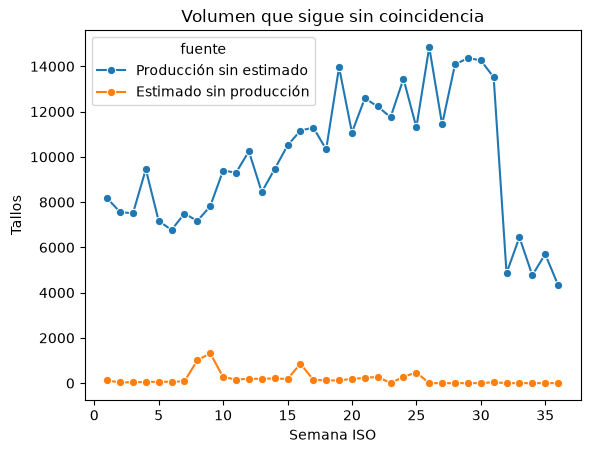

In [43]:
display(produccion_pendiente_final.head(30))
display(estimado_pendiente_final.head(30))

pendientes_grafica = pd.concat([
    produccion_pendiente_final.groupby("semana", as_index=False)["tallos_reales"].sum()
        .rename(columns={"tallos_reales": "tallos"}).assign(fuente="Producción sin estimado"),
    estimado_pendiente_final.groupby("semana", as_index=False)["tallos_estimados"].sum()
        .rename(columns={"tallos_estimados": "tallos"}).assign(fuente="Estimado sin producción")
])
sns.lineplot(data=pendientes_grafica, x="semana", y="tallos", hue="fuente", marker="o")
plt.title("Volumen que sigue sin coincidencia")
plt.xlabel("Semana ISO"); plt.ylabel("Tallos"); plt.show()

In [44]:
df = produccion_pendiente_final[produccion_pendiente_final["tallos_reales"]!=0].copy()

In [45]:
df = estimado_pendiente_final[estimado_pendiente_final["tallos_estimados"]!=0].copy()

In [46]:
df.shape

(33, 9)

In [47]:
df

,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
8,2026,1,ARABELLA,CARNATION,RED,VIRGILIO,90.0,NaN,solo_estimado
51,2026,1,GAITANA,CARNATION,YELLOW,SPLENDOR,30.0,NaN,solo_estimado
148,2026,2,GAITANA,CARNATION,YELLOW,SPLENDOR,30.0,NaN,solo_estimado
245,2026,3,GAITANA,CARNATION,YELLOW,SPLENDOR,40.0,NaN,solo_estimado
341,2026,4,GAITANA,CARNATION,YELLOW,SPLENDOR,50.0,NaN,solo_estimado
432,2026,5,GAITANA,CARNATION,YELLOW,SPLENDOR,60.0,NaN,solo_estimado
518,2026,6,GAITANA,CARNATION,YELLOW,SPLENDOR,60.0,NaN,solo_estimado
603,2026,7,GAITANA,CARNATION,YELLOW,SPLENDOR,80.0,NaN,solo_estimado
650,2026,8,ARABELLA,CARNATION,VINTAGE,MARBLE,100.0,NaN,solo_estimado
655,2026,8,ARABELLA,CARNATION,GREEN,ZUMO,820.0,NaN,solo_estimado


In [48]:
produccion_pendiente_final[(produccion_pendiente_final['k_producto']=='CARNATION') & (produccion_pendiente_final['k_variedad']=='SPLENDOR')]

,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
2584,2026,25,ARABELLA,CARNATION,YELLOW,SPLENDOR,NaN,6.0,solo_produccion
2663,2026,26,ARABELLA,CARNATION,YELLOW,SPLENDOR,NaN,137.0,solo_produccion


In [49]:
consolidado_benchmak = pd.concat([
    coincidencias_estrictas,
    recuperados_por_variedad,
    estimado_pendiente_final,
    produccion_pendiente_final
], ignore_index=True)

In [50]:
df_prod_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 939805 entries, 0 to 939804
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Finca              939805 non-null  str           
 1   Invernadero        939805 non-null  str           
 2   Fecha Corte        939805 non-null  datetime64[us]
 3   Año                939805 non-null  int64         
 4   Semana             939805 non-null  int64         
 5   Tipo Corte         939805 non-null  str           
 6   Producto           939805 non-null  str           
 7   Grado              939805 non-null  str           
 8   Color              939805 non-null  str           
 9   Variedad           939805 non-null  str           
 10  Tallos             939805 non-null  int64         
 11  Lote               939805 non-null  int64         
 12  Estado Inventario  939805 non-null  str           
 13  Hora Corte         939805 non-null  object        
 14 

In [51]:
estimados_H1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7282 entries, 0 to 7281
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   anio_inicial_estimado       7282 non-null   int64         
 1   semana_inicial_estimado     7282 non-null   int64         
 2   semanas_adelante            7282 non-null   int64         
 3   lunes_objetivo              7282 non-null   datetime64[us]
 4   archivo_origen              7282 non-null   str           
 5   semana_archivo              7282 non-null   int64         
 6   archivo_es_posterior        7282 non-null   bool          
 7   diferencia_semanas_archivo  7282 non-null   int64         
 8   CODFINCA                    7282 non-null   str           
 9   PRODUCTO                    7282 non-null   str           
 10  COLOR                       7282 non-null   str           
 11  VARIEDAD                    7282 non-null   str           
 12  EST

In [52]:
#validaciones con data inicial

#desde el original
print("=" * 100)
print("desde los estimados y producción originales")
print("Suma producción real original:", df_prod_clean["Tallos"].sum())
print("Suma estimado original:", estimados_H1["ESTI. EXPORTABLE"].sum())
print("=" * 100)
#desde los agregados
print("=" * 100)
print("desde los estimados y producción agregados")
print("Suma producción real agregada:", prod_agregado["tallos_reales"].sum())
print("Suma estimado agregada:", est_agregado["tallos_estimados"].sum())
print("=" * 100)
print("Coincidencias estrictas:", len(coincidencias_estrictas))
print("Solo estimado después de unión estricta:", len(estimado_pendiente_tras_union_estricta))
print("Solo producción después de unión estricta:", len(produccion_pendiente_tras_union_estricta))
print("La suma de las 3 shapes:", len(coincidencias_estrictas) + len(estimado_pendiente_tras_union_estricta) + len(produccion_pendiente_tras_union_estricta))
print("=" * 100)
# Las mismas metricas despues de la unión consolidada del benchmark
print("=" * 100)
print("shape del consolidado benchmark:", consolidado_benchmak.shape)
print("Suma producción real consolidada:", consolidado_benchmak["tallos_reales"].sum())
print("Suma estimado consolidada:", consolidado_benchmak["tallos_estimados"].sum())
print("=" * 100)


desde los estimados y producción originales
Suma producción real original: 66493635
Suma estimado original: 64956721
desde los estimados y producción agregados
Suma producción real agregada: 66493635
Suma estimado agregada: 62771591
Coincidencias estrictas: 5295
Solo estimado después de unión estricta: 1710
Solo producción después de unión estricta: 2241
La suma de las 3 shapes: 9246
shape del consolidado benchmark: (8802, 9)
Suma producción real consolidada: 66493635.0
Suma estimado consolidada: 62771591.0


In [53]:
consolidado_benchmak

,anio,semana,k_finca,k_producto,k_color,k_variedad,tallos_estimados,tallos_reales,estado
0,2026,1,ARABELLA,CARNATION,BICOLOR BURGUNDY,PERFECT,11640.0,11214.0,coincide
1,2026,1,ARABELLA,CARNATION,BICOLOR PINK,SPRITZ BIANCO ROSA,4540.0,5393.0,coincide
2,2026,1,ARABELLA,CARNATION,BICOLOR PURPLE,DAMASCUS,9440.0,6935.0,coincide
3,2026,1,ARABELLA,CARNATION,BICOLOR PURPLE,KINO,5670.0,4251.0,coincide
4,2026,1,ARABELLA,CARNATION,BICOLOR RED,SORRISO,8960.0,8900.0,coincide
...,...,...,...,...,...,...,...,...,...
8797,2026,36,GAITANA,STATICE,WHITE,GLACIER TROPHY,NaN,380.0,solo_produccion
8798,2026,36,GAITANA,STATICE,HOT PINK,MUSICAL WINGS,NaN,380.0,solo_produccion
8799,2026,36,GAITANA,STATICE,PURPLE,PIPPA WINGS,NaN,280.0,solo_produccion
8800,2026,36,GAITANA,STATICE,HOT PINK,RASPBERRY WINGS,NaN,100.0,solo_produccion


In [54]:
consolidado_benchmak.to_excel("consolidado_benchmark.xlsx", index=False)

### 6. Informe gerencial interactivo del benchmark H1

Se utiliza temporalmente `consolidado_benchmark.xlsx`, ya exportado en esta carpeta. Esta sección puede ejecutarse sola: no requiere volver a ejecutar la extracción ni las uniones anteriores.

El informe incluye resumen, evolución semanal, finca, producto, color, variedad y detalle, con filtros compartidos. Los errores se calculan por registro semanal antes de agrupar. Los faltantes debidos a la unión se toman como cero, conservando las cantidades originales. Las uniones por variedad se identifican porque su color prioriza el del estimado.

El HTML funciona sin conexión; el Excel contiene el periodo completo. Desde cada pestaña del HTML se puede descargar la tabla filtrada en CSV. El control de semanas se toma de la salida guardada de este notebook, cuando está disponible.


In [55]:
from pathlib import Path
import importlib.util
from IPython.display import display, FileLink

# Funciona tanto desde la raíz del proyecto como desde Notebooks.
carpeta_actual = Path.cwd().resolve()
raiz_proyecto = next(
    carpeta for carpeta in [carpeta_actual, *carpeta_actual.parents]
    if (carpeta / "scripts" / "generar_informe_benchmark.py").exists()
)
ruta_script = raiz_proyecto / "scripts" / "generar_informe_benchmark.py"
spec = importlib.util.spec_from_file_location("informe_benchmark", ruta_script)
informe = importlib.util.module_from_spec(spec)
spec.loader.exec_module(informe)

resultado_informe = informe.generar_informe(
    archivo=raiz_proyecto / "Notebooks" / "consolidado_benchmark.xlsx",
    salida=raiz_proyecto / "Notebooks" / "informes"
)

base_benchmark_informe = resultado_informe["base"]
resumen_semanal_h1 = informe.resumir(base_benchmark_informe, ["anio", "semana"])

display(resultado_informe["resumen"])
for formato in ["html", "excel"]:
    ruta = resultado_informe[formato]
    print(f"{formato.upper()}: {ruta}")
    try:
        display(FileLink(str(ruta.relative_to(carpeta_actual))))
    except ValueError:
        display(FileLink(str(ruta)))


,registros,comparaciones,por_revisar,tallos_estimados,tallos_reales,diferencia_tallos,error_absoluto_total,MAE_tallos,WAPE_pct,sesgo_pct,participacion_error_pct,sobreestimacion_tallos,subestimacion_tallos,solo_estimado,solo_produccion,sin_contraparte_con_volumen,sin_contraparte_cero,unido_variedad
0,8802,8802,0,62771591.0,66493635.0,-3722044.0,12312668.0,1398.848898,18.517063,-5.597594,100.0,4295312.0,8017356.0,1266,1797,1830,1233,444


HTML: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\informes\informe_gerencia_benchmark.html


C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\informes\informe_gerencia_benchmark.html

EXCEL: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\informes\informe_gerencia_benchmark.xlsx


C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\informes\informe_gerencia_benchmark.xlsx